XGBOOST - Week - Quantile

In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des données
Lecture du fichier CSV contenant les relevés piézométriques du piézomètre Bourdet.

In [3]:
from hydrosense.database.bigquery import load_piezo_bq
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense import params

In [4]:
DATA_CODE_PIEZO = "BSS001QSMT" #"BSS001PHQG" #"BSS001GNWX" #  "BSS001QSMT" #BSS001QHYH"

In [5]:
load_piezo_bq(DATA_CODE_PIEZO)

pem_BSS001QSMT
ok
BSS001QSMT : 8713 lignes chargées


,date_mesure,niveau_nappe_eau,RR_synth
0,2002-07-23,107.58,0.98
1,2002-07-24,107.50,0.00
2,2002-07-25,107.44,0.00
3,2002-07-26,107.38,0.00
4,2002-07-27,107.34,0.00
...,...,...,...
8708,2026-05-26,110.85,0.02
8709,2026-05-27,110.83,0.01
8710,2026-05-28,110.80,0.00
8711,2026-05-29,110.77,0.00


In [6]:
df = clean_piezo(load_piezo_bq(DATA_CODE_PIEZO))

pem_BSS001QSMT
ok
BSS001QSMT : 8713 lignes chargées
DataFrame final : 2002-07-23 00:00:00 → 2026-05-30 00:00:00 | 8713 jours


### Mise en forme de l'index
Conversion de la colonne `date_mesure` en index temporel de type `DatetimeIndex`.

> **Pourquoi ?** Les méthodes de séries temporelles comme `resample()` nécessitent
> un index de type `DatetimeIndex`. En définissant la date comme index, on peut
> ensuite rééchantillonner, découper et aligner les données par date facilement.

In [7]:
# Vérifie que la colonne date_mesure est bien présente (pas encore en index)
if 'date_mesure' in df.columns:
    df.set_index('date_mesure', inplace=True)

# S'assure que l'index est bien de type DatetimeIndex
df.index = pd.to_datetime(df.index)

df.head()

,niveau_nappe_eau
date_mesure,
2002-07-23,107.58
2002-07-24,107.50
2002-07-25,107.44
2002-07-26,107.38
2002-07-27,107.34


In [8]:
# 'ME' = Month End (anciennement 'M', déprécié depuis pandas 2.2)
y_week = df["niveau_nappe_eau"].resample('W').mean()
y_week

date_mesure
2002-07-28    107.418333
2002-08-04    107.101429
2002-08-11    106.915714
2002-08-18    106.785714
2002-08-25    106.634286
                 ...    
2026-05-03    111.465714
2026-05-10    111.300000
2026-05-17    111.157143
2026-05-24    110.987143
2026-05-31    110.810000
Freq: W-SUN, Name: niveau_nappe_eau, Length: 1245, dtype: float64

In [9]:
# 1. Préparation des colonnes (Lag)
df_w = pd.DataFrame(y_week)
df_w['semaine'] = df_w.index.isocalendar().week
df_w['lag_1'] = df_w['niveau_nappe_eau'].shift(1)
df_w['lag_2'] = df_w['niveau_nappe_eau'].shift(2)
df_w['lag_3'] = df_w['niveau_nappe_eau'].shift(3)
df_w['lag_4'] = df_w['niveau_nappe_eau'].shift(4)
df_w['lag_52'] = df_w['niveau_nappe_eau'].shift(52)


In [10]:
# Moyenne du niveau de la nappe sur les 3 derniers mois (tendance récente)
df_w['moyenne_3w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=3).mean()

# Moyenne du niveau sur les 6 derniers mois (tendance moyen terme)
df_w['moyenne_6w'] = df_w['niveau_nappe_eau'].shift(1).rolling(window=6).mean()

In [11]:
# IMPORTANT : Applique le .dropna() APRÈS avoir créé ces nouvelles variables
df_w = df_w.dropna()

X = df_w[['semaine', 'lag_1', 'lag_2', 'lag_3','lag_4', 'lag_52', 'moyenne_3w', 'moyenne_6w']]

y_target = df_w['niveau_nappe_eau']

# Split Train / Test
X_train, X_test = X.loc[:'2026-02-28'], X.loc['2026-03-01':'2026-05-31']
y_train, y_test = y_target.loc[:'2026-02-28'], y_target.loc['2026-03-01':'2026-05-31']

In [12]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import pandas as pd

# 1. On définit la grille des paramètres à tester
param_grid_xgb = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'subsample': [0.6,0.7,0.8],
    'colsample_bytree': [0.5,0.6, 0.7],
    "min_child_weight": [3, 5, 10]
}


# 2. Instanciation du modèle de base
xgb_base = XGBRegressor(random_state=42)

# 3. Configuration de la recherche automatique (avec 3 découpages de validation)
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# 4. Entraînement sur tes données (X_train et y_train avec les Lags)
grid_search_xgb.fit(X_train, y_train)

# 5. Affichage des meilleurs réglages trouvés
print("Meilleurs paramètres XGBoost :", grid_search_xgb.best_params_)


Meilleurs paramètres XGBoost : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 500, 'subsample': 0.7}


In [13]:
grid_search_xgb.best_params_ = {'colsample_bytree': 0.6,
 'learning_rate': 0.1,
 'max_depth': 2,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.8,
 }

In [14]:
grid_search_xgb.best_params_

{'colsample_bytree': 0.6,
 'learning_rate': 0.1,
 'max_depth': 2,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.8}

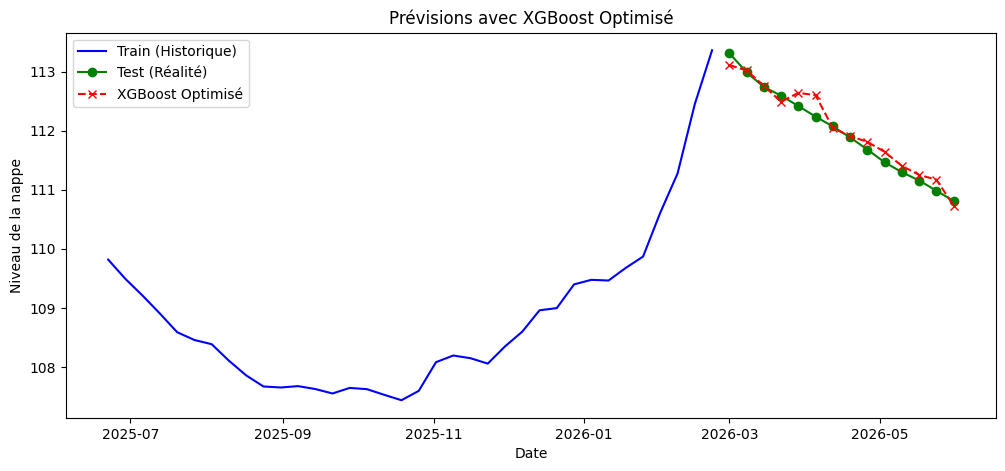

In [15]:
# 1. Récupération du meilleur modèle
best_xgb = grid_search_xgb.best_estimator_

# 2. Prédiction sur l'année de test
forecast_xgb_opt = pd.Series(best_xgb.predict(X_test), index=y_test.index)

# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))
plt.plot(y_train.tail(36), label='Train (Historique)', color='blue')
plt.plot(y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()

In [16]:

y_mensuel = df["niveau_nappe_eau"].resample('ME').mean()
y_mensuel

date_mesure
2002-07-31    107.335556
2002-08-31    106.824839
2002-09-30    106.881333
2002-10-31    106.680968
2002-11-30    107.438667
                 ...    
2026-01-31    109.819677
2026-02-28    112.519643
2026-03-31    112.677097
2026-04-30    111.888000
2026-05-31    111.105667
Freq: ME, Name: niveau_nappe_eau, Length: 287, dtype: float64

In [17]:

seuils_hebdo = df_w.groupby('semaine').agg(
    P95=('niveau_nappe_eau', lambda x: x.quantile(0.95)),
    P85=('niveau_nappe_eau', lambda x: x.quantile(0.85)),
    P50=('niveau_nappe_eau', lambda x: x.quantile(0.50)),
    P20=('niveau_nappe_eau', lambda x: x.quantile(0.20)),
    P10=('niveau_nappe_eau', lambda x: x.quantile(0.10)),
    P5 =('niveau_nappe_eau', lambda x: x.quantile(0.05))
).to_dict(orient='index')

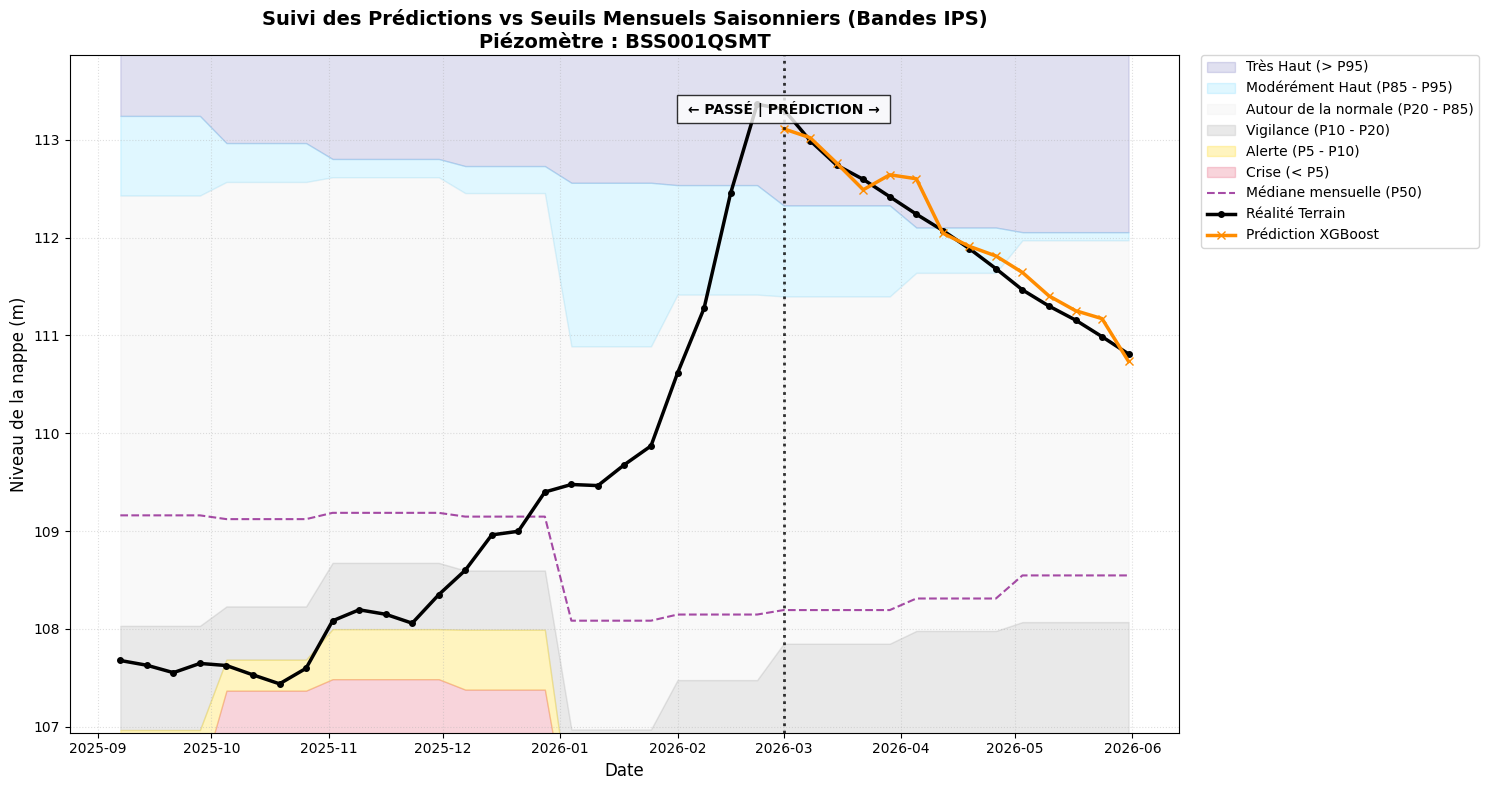

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. PRÉPARATION DES DONNÉES (Histoire 6 mois + Test)
# ══════════════════════════════════════════════════════════════════════════════

# Définition de la date de départ (6 mois avant mars 2026 -> septembre 2025)
date_debut_historique = '2025-09-01'

# Extraction des 6 mois réels depuis y_train
y_historique_6m = y_train.loc[date_debut_historique:]

# Fusion pour obtenir la courbe noire continue de la Réalité Terrain
y_reel_complet = pd.concat([y_historique_6m, y_test])


# ══════════════════════════════════════════════════════════════════════════════
# 2. EXTRACTION DYNAMIQUE DES SEUILS MENSUELS POUR CHAQUE DATE
# ══════════════════════════════════════════════════════════════════════════════

# On récupère le numéro de mois pour CHAQUE date de notre axe X complet
mois_complet = y_reel_complet.index.month

# On crée les listes de seuils associées à chaque point dans le temps
s_p95 = [seuils_hebdo[m]['P95'] for m in mois_complet]
s_p85 = [seuils_hebdo[m]['P85'] for m in mois_complet]
s_p50 = [seuils_hebdo[m]['P50'] for m in mois_complet]
s_p20 = [seuils_hebdo[m]['P20'] for m in mois_complet]
s_p10 = [seuils_hebdo[m]['P10'] for m in mois_complet]
s_p5  = [seuils_hebdo[m]['P5']  for m in mois_complet]

# Bornes artificielles pour remplir le haut et le bas du graphique sans limite
ymin, ymax = y_reel_complet.min() - 2, y_reel_complet.max() + 2


# ══════════════════════════════════════════════════════════════════════════════
# 3. TRACÉ DES BANDES DE COULEURS SAISONNIÈRES (fill_between)
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(15, 8))

# Zone TRÈS HAUTE (Au-dessus du P95) -> Bleu foncé
plt.fill_between(y_reel_complet.index, s_p95, ymax, color='darkblue', alpha=0.12, label='Très Haut (> P95)')

# Zone MODÉRÉMENT HAUTE (Entre P85 et P95) -> Bleu clair
plt.fill_between(y_reel_complet.index, s_p85, s_p95, color='deepskyblue', alpha=0.12, label='Modérément Haut (P85 - P95)')

# Zone NORMALE (Entre P20 et P85) -> Zone grise neutre
plt.fill_between(y_reel_complet.index, s_p20, s_p85, color='gainsboro', alpha=0.15, label='Autour de la normale (P20 - P85)')

# Zone VIGILANCE (Entre P10 et P20) -> Gris foncé
plt.fill_between(y_reel_complet.index, s_p10, s_p20, color='darkgray', alpha=0.25, label='Vigilance (P10 - P20)')

# Zone ALERTE (Entre P5 et P10) -> Jaune / Or
plt.fill_between(y_reel_complet.index, s_p5, s_p10, color='gold', alpha=0.25, label='Alerte (P5 - P10)')

# Zone CRISE (En-dessous du P5) -> Rouge / Crimson
plt.fill_between(y_reel_complet.index, ymin, s_p5, color='crimson', alpha=0.18, label='Crise (< P5)')


# ══════════════════════════════════════════════════════════════════════════════
# 4. TRACÉ DES COURBES ET REPERES
# ══════════════════════════════════════════════════════════════════════════════

# Courbe de la Médiane mensuelle (P50) qui ondule aussi
plt.plot(y_reel_complet.index, s_p50, color='purple', linestyle='--', linewidth=1.5, alpha=0.7, label='Médiane mensuelle (P50)')

# Courbe Réalité Terrain (6 mois d'histoire + 3 mois de test)
plt.plot(y_reel_complet.index, y_reel_complet, label='Réalité Terrain', color='black', marker='o', linewidth=2.5, markersize=4)

# Courbe Prédiction XGBoost (Se cale pile sur l'index de y_test)
plt.plot(y_test.index, forecast_xgb_opt, label='Prédiction XGBoost', color='darkorange', linestyle='-', marker='x', linewidth=2.5, markersize=6)

# Ligne verticale de séparation Passé (Connu) / Futur (Prédit)
plt.axvline(x=y_test.index[0], color='black', linestyle=':', linewidth=2, alpha=0.8)
plt.text(y_test.index[0], y_reel_complet.max() - 0.1, ' ← PASSÉ | PRÉDICTION → ',
         fontsize=10, fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.8))


# ══════════════════════════════════════════════════════════════════════════════
# 5. HABILLAGE DU GRAPHIQUE
# ══════════════════════════════════════════════════════════════════════════════
plt.title(f"Suivi des Prédictions vs Seuils Mensuels Saisonniers (Bandes IPS)\nPiézomètre : {DATA_CODE_PIEZO}", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Niveau de la nappe (m)", fontsize=12)

# On restreint l'affichage Y pour centrer le graphique sur l'essentiel
plt.ylim(y_reel_complet.min() - 0.5, y_reel_complet.max() + 0.5)

# Légende déportée à droite
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., frameon=True, facecolor='white')

plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()

plt.show()

In [19]:
# Calcul des percentiles sur tout l'historique d'un coup (valeurs fixes)
p95_global = df_w['niveau_nappe_eau'].quantile(0.95)
p85_global = df_w['niveau_nappe_eau'].quantile(0.85)
p50_global = df_w['niveau_nappe_eau'].quantile(0.50)
p20_global = df_w['niveau_nappe_eau'].quantile(0.20)
p10_global = df_w['niveau_nappe_eau'].quantile(0.10)
p5_global  = df_w['niveau_nappe_eau'].quantile(0.05)

In [20]:
p5_global


np.float64(105.61885714285715)

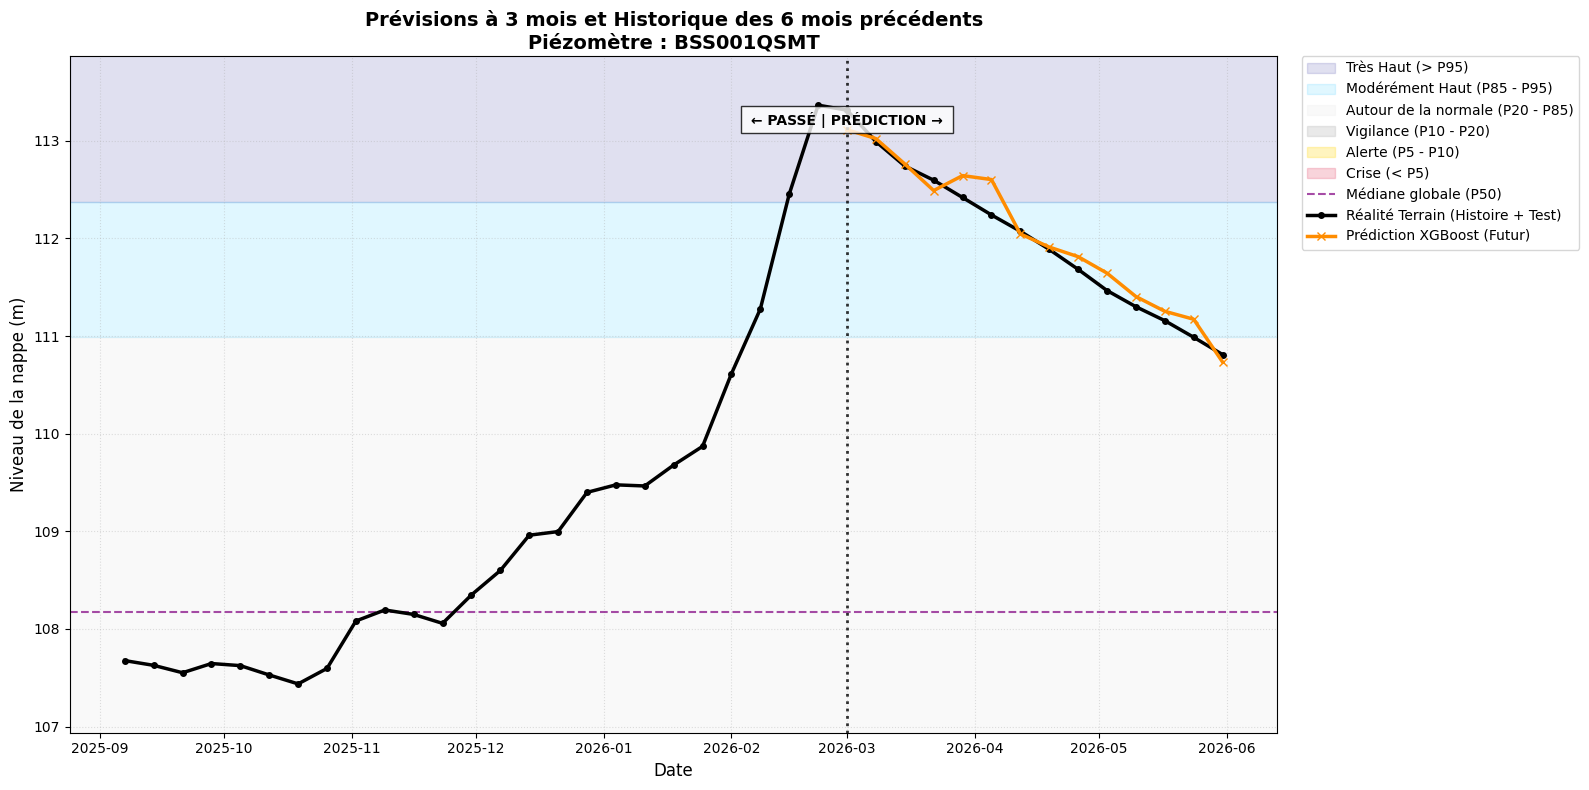

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════════════════════════
# 1. RÉCUPÉRATION DES 6 MOIS PRÉCÉDENTS
# ══════════════════════════════════════════════════════════════════════════════

# On définit la date de début (6 mois avant le début du test qui commence le 2026-03-01)
# 6 mois avant mars 2026 -> septembre 2025
date_debut_historique = '2025-09-01'

# On extrait l'historique réel depuis y_train
y_historique_6m = y_train.loc[date_debut_historique:]

# On fusionne l'historique des 6 mois et la réalité du test pour avoir la courbe noire complète
y_reel_complet = pd.concat([y_historique_6m, y_test])


# ══════════════════════════════════════════════════════════════════════════════
# 2. PRÉPARATION DU GRAPHIQUE
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(16, 8))

# Bornes dynamiques basées sur le signal complet pour caler les bandes de couleur
ymin, ymax = y_reel_complet.min() - 2, y_reel_complet.max() + 2


# ══════════════════════════════════════════════════════════════════════════════
# 3. TRACÉ DES BANDES HORIZONTALES (axhspan s'étend sur tout l'axe X automatiquement)
# ══════════════════════════════════════════════════════════════════════════════
plt.axhspan(p95_global, ymax, color='darkblue', alpha=0.12, label='Très Haut (> P95)')
plt.axhspan(p85_global, p95_global, color='deepskyblue', alpha=0.12, label='Modérément Haut (P85 - P95)')
plt.axhspan(p20_global, p85_global, color='gainsboro', alpha=0.15, label='Autour de la normale (P20 - P85)')
plt.axhspan(p10_global, p20_global, color='darkgray', alpha=0.25, label='Vigilance (P10 - P20)')
plt.axhspan(p5_global, p10_global, color='gold', alpha=0.25, label='Alerte (P5 - P10)')
plt.axhspan(ymin, p5_global, color='crimson', alpha=0.18, label='Crise (< P5)')

# Ligne droite pour la Médiane (P50)
plt.axhline(y=p50_global, color='purple', linestyle='--', linewidth=1.5, alpha=0.7, label='Médiane globale (P50)')


# ══════════════════════════════════════════════════════════════════════════════
# 4. TRACÉ DES COURBES (Réalité vs Prédiction)
# ══════════════════════════════════════════════════════════════════════════════

# A. La réalité terrain : on trace la courbe COMPLETE (6 mois d'histoire + 3 mois de test)
plt.plot(y_reel_complet.index, y_reel_complet, label='Réalité Terrain (Histoire + Test)', color='black', marker='o', linewidth=2.5, markersize=4)

# B. La prédiction XGBoost : elle ne commence QU'À LA DATE DU TEST
# On utilise l'index de y_test pour qu'elle se positionne pile au bon endroit à droite du graphique
plt.plot(y_test.index, forecast_xgb_opt, label='Prédiction XGBoost (Futur)', color='darkorange', linestyle='-', marker='x', linewidth=2.5, markersize=6)

# C. Optionnel : Ajout d'une ligne verticale pointillée pour séparer le Passé du Futur
plt.axvline(x=y_test.index[0], color='black', linestyle=':', linewidth=2, alpha=0.8)
plt.text(y_test.index[0], y_reel_complet.max() - 0.2, ' ← PASSÉ | PRÉDICTION → ', fontsize=10, fontweight='bold', ha='center', bbox=dict(facecolor='white', alpha=0.8))


# ══════════════════════════════════════════════════════════════════════════════
# 5. CONFIGURATION VISUELLE
# ══════════════════════════════════════════════════════════════════════════════
plt.title(f"Prévisions à 3 mois et Historique des 6 mois précédents\nPiézomètre : {DATA_CODE_PIEZO}", fontsize=14, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Niveau de la nappe (m)", fontsize=12)

# Ajustement des axes Y pour englober tout le signal proprement
plt.ylim(y_reel_complet.min() - 0.5, y_reel_complet.max() + 0.5)

# Légende à droite
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., facecolor='white')

plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.tight_layout()

plt.show()

In [39]:
import time


import numpy as np
import pandas as pd

from pathlib import Path
from colorama import Fore, Style

from hydrosense.ml_logic.model import initialize_model, optimize_model, train_model, evaluate_model, predict_model

from hydrosense.preprocess.cleaning import clean_piezo2

from hydrosense.database.bigquery import load_piezo_bq
from hydrosense.preprocess.cleaning import clean_piezo
from hydrosense.preprocess.preprocessor import preprocess_week
from hydrosense.interface.main import split_data, preprocess_week,train,evaluate,pred

from hydrosense import params

In [40]:
df = load_piezo_bq(DATA_CODE_PIEZO)
df

pem_BSS001QSMT
ok
BSS001QSMT : 8713 lignes chargées


,date_mesure,niveau_nappe_eau,RR_synth
0,2002-07-23,107.58,0.98
1,2002-07-24,107.50,0.00
2,2002-07-25,107.44,0.00
3,2002-07-26,107.38,0.00
4,2002-07-27,107.34,0.00
...,...,...,...
8708,2026-05-26,110.85,0.02
8709,2026-05-27,110.83,0.01
8710,2026-05-28,110.80,0.00
8711,2026-05-29,110.77,0.00


In [42]:


# load from big query
df = clean_piezo2(df)
df


             niveau_nappe_eau  RR_synth
date_mesure                            
2002-07-23             107.58      0.98
2002-07-24             107.50      0.00
2002-07-25             107.44      0.00
2002-07-26             107.38      0.00
2002-07-27             107.34      0.00
...                       ...       ...
2026-05-26             110.85      0.02
2026-05-27             110.83      0.01
2026-05-28             110.80      0.00
2026-05-29             110.77      0.00
2026-05-30             110.73      0.00

[8713 rows x 2 columns]
DataFrame final : 2002-07-23 → 2026-05-30 | 8713 jours


,date_mesure,niveau_nappe_eau,RR_synth
0,2002-07-23,107.58,0.98
1,2002-07-24,107.50,0.00
2,2002-07-25,107.44,0.00
3,2002-07-26,107.38,0.00
4,2002-07-27,107.34,0.00
...,...,...,...
8708,2026-05-26,110.85,0.02
8709,2026-05-27,110.83,0.01
8710,2026-05-28,110.80,0.00
8711,2026-05-29,110.77,0.00


In [43]:
df_ml = preprocess_week(df)
df_ml



⭐️ Use case: preprocess
✅ preprocess() done — 1193 semaines | 10 colonnes



,niveau_nappe_eau,RR_synth,semaine,lag_1,lag_2,lag_3,lag_4,lag_52,moyenne_3w,moyenne_6w
date_mesure,,,,,,,,,,
2003-07-27,107.714286,8.49,30,107.970000,108.302857,108.657143,108.980000,107.418333,108.310000,108.813571
2003-08-03,107.345714,0.41,31,107.714286,107.970000,108.302857,108.657143,107.101429,107.995714,108.503571
2003-08-10,106.990000,0.00,32,107.345714,107.714286,107.970000,108.302857,106.915714,107.676667,108.161667
2003-08-17,106.652857,5.81,33,106.990000,107.345714,107.714286,107.970000,106.785714,107.350000,107.830000
2003-08-24,106.370000,9.60,34,106.652857,106.990000,107.345714,107.714286,106.634286,106.996190,107.495952
...,...,...,...,...,...,...,...,...,...,...
2026-05-03,111.465714,15.00,18,111.682857,111.887143,112.072857,112.240000,111.344286,111.880952,112.149524
2026-05-10,111.300000,55.48,19,111.465714,111.682857,111.887143,112.072857,111.212857,111.678571,111.961190
2026-05-17,111.157143,16.66,20,111.300000,111.465714,111.682857,111.887143,111.045714,111.482857,111.774762


In [44]:
df_ml.head()

,niveau_nappe_eau,RR_synth,semaine,lag_1,lag_2,lag_3,lag_4,lag_52,moyenne_3w,moyenne_6w
date_mesure,,,,,,,,,,
2003-07-27,107.714286,8.49,30,107.970000,108.302857,108.657143,108.980000,107.418333,108.310000,108.813571
2003-08-03,107.345714,0.41,31,107.714286,107.970000,108.302857,108.657143,107.101429,107.995714,108.503571
2003-08-10,106.990000,0.00,32,107.345714,107.714286,107.970000,108.302857,106.915714,107.676667,108.161667
2003-08-17,106.652857,5.81,33,106.990000,107.345714,107.714286,107.970000,106.785714,107.350000,107.830000
2003-08-24,106.370000,9.60,34,106.652857,106.990000,107.345714,107.714286,106.634286,106.996190,107.495952


In [45]:
df_ml['semaine'] = df_ml.index.isocalendar().week.astype(int)

    # 💡 AJOUT DES COLONNES SINUS ET COSINUS
    # On divise par 52 (le nombre total de semaines dans l'année)
df_ml['semaine_sin'] = np.sin(2 * np.pi * df_ml['semaine'] / 52)
df_ml['semaine_cos'] = np.cos(2 * np.pi * df_ml['semaine'] / 52)

In [46]:
df_ml.head()

,niveau_nappe_eau,RR_synth,semaine,lag_1,lag_2,lag_3,lag_4,lag_52,moyenne_3w,moyenne_6w,semaine_sin,semaine_cos
date_mesure,,,,,,,,,,,,
2003-07-27,107.714286,8.49,30,107.970000,108.302857,108.657143,108.980000,107.418333,108.310000,108.813571,-0.464723,-0.885456
2003-08-03,107.345714,0.41,31,107.714286,107.970000,108.302857,108.657143,107.101429,107.995714,108.503571,-0.568065,-0.822984
2003-08-10,106.990000,0.00,32,107.345714,107.714286,107.970000,108.302857,106.915714,107.676667,108.161667,-0.663123,-0.748511
2003-08-17,106.652857,5.81,33,106.990000,107.345714,107.714286,107.970000,106.785714,107.350000,107.830000,-0.748511,-0.663123
2003-08-24,106.370000,9.60,34,106.652857,106.990000,107.345714,107.714286,106.634286,106.996190,107.495952,-0.822984,-0.568065


In [49]:
from hydrosense.interface.main import split_data

In [50]:
X_train, X_test, y_train, y_test = split_data(df_ml)



⭐️ Use case: split_data
['semaine_sin', 'semaine_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_52', 'moyenne_3w', 'moyenne_6w', 'RR_synth']
✅ split_data() done — Train : 1179 semaines | Test : 14 semaines



In [51]:
y_train

array([107.71428571, 107.34571429, 106.99      , ..., 111.27714286,
       112.45285714, 113.36428571], shape=(1179,))

In [52]:
# 2. Train — optimize=True pour GridSearchCV
#model, history = train(X_train, y_train, optimize=True)
model, history = train(X_train, y_train, optimize=False)



⭐️ Use case: train
✅ Model initialized

Training model...
✅ Model trained on 1179 rows in 0.75s
   Train MAE  : 0.0834
   Train RMSE : 0.1182
✅ train() done 



In [53]:
# 3. Evaluate — même modèle, pas de rechargement
metrics = evaluate(model, X_test, y_test)



⭐️ Use case: evaluate

Evaluating model on 14 rows...
✅ Model evaluated on test set
   MAE  : 0.126  (erreur moyenne en mètres NGF)
   RMSE : 0.1749 (pénalise les grandes erreurs)
   R²   : 0.9457  (1.0 = parfait)
✅ evaluate() done 



In [54]:

# 4. Predict — prévision 3 mois futurs
forecast_xgb_opt = pred(model, df_ml)


⭐️ Use case: pred
✅ Predicted 14 values

✅ pred() done — Predicted 14 weeks:
date_mesure
2026-03-01    113.132858
2026-03-08    113.148750
2026-03-15    112.548996
2026-03-22    112.438705
2026-03-29    112.396408
2026-04-05    112.448074
2026-04-12    111.991180
2026-04-19    111.875893
2026-04-26    111.792564
2026-05-03    111.554276
2026-05-10    111.784157
2026-05-17    111.154419
2026-05-24    111.055290
2026-05-31    110.809410
Freq: W-SUN



In [55]:
y_test

array([113.31285714, 112.99142857, 112.74142857, 112.59571429,
       112.41857143, 112.24      , 112.07285714, 111.88714286,
       111.68285714, 111.46571429, 111.3       , 111.15714286,
       110.98714286, 110.81      ])

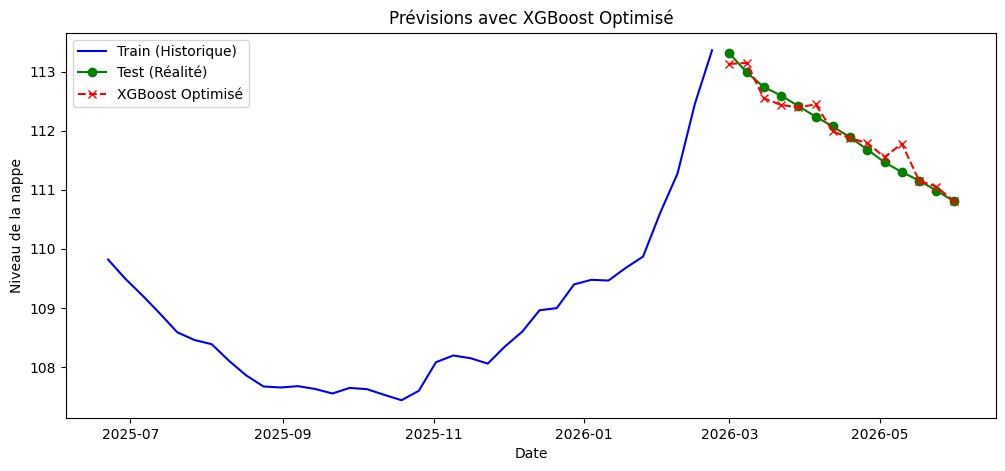

In [56]:


# 💡 CORRECTION : On récupère le vrai index temporel depuis df_ml
# Assure-toi que EVALUATION_START_DATE et TEST_END sont bien définis
test_dates = df_ml.loc[params.EVALUATION_START_DATE:"2026-05-31"].index



# 3. Graphique de comparaison
plt.figure(figsize=(12, 5))

# 💡 CORRECTION POUR LE GRAPH : y_train et y_test étant des numpy arrays,
# on doit aussi leur associer des index de dates pour que Matplotlib les place au bon endroit !
train_dates = df_ml.loc[:"2026-02-28"].index

plt.plot(train_dates[-36:], y_train[-36:], label='Train (Historique)', color='blue')
plt.plot(test_dates, y_test, label='Test (Réalité)', color='green', marker='o')
plt.plot(forecast_xgb_opt.index, forecast_xgb_opt, label='XGBoost Optimisé', color='red', linestyle='--', marker='x')

plt.title("Prévisions avec XGBoost Optimisé")
plt.xlabel("Date")
plt.ylabel("Niveau de la nappe")
plt.legend()
plt.show()

In [57]:
df_ml.head()

,niveau_nappe_eau,RR_synth,semaine,lag_1,lag_2,lag_3,lag_4,lag_52,moyenne_3w,moyenne_6w,semaine_sin,semaine_cos
date_mesure,,,,,,,,,,,,
2003-07-27,107.714286,8.49,30,107.970000,108.302857,108.657143,108.980000,107.418333,108.310000,108.813571,-0.464723,-0.885456
2003-08-03,107.345714,0.41,31,107.714286,107.970000,108.302857,108.657143,107.101429,107.995714,108.503571,-0.568065,-0.822984
2003-08-10,106.990000,0.00,32,107.345714,107.714286,107.970000,108.302857,106.915714,107.676667,108.161667,-0.663123,-0.748511
2003-08-17,106.652857,5.81,33,106.990000,107.345714,107.714286,107.970000,106.785714,107.350000,107.830000,-0.748511,-0.663123
2003-08-24,106.370000,9.60,34,106.652857,106.990000,107.345714,107.714286,106.634286,106.996190,107.495952,-0.822984,-0.568065


In [38]:
forecast_xgb_opt

date_mesure
2026-03-01    113.365417
2026-03-08    113.236534
2026-03-15    112.663628
2026-03-22    112.431335
2026-03-29    112.348022
2026-04-05    112.238083
2026-04-12    111.993935
2026-04-19    111.810089
2026-04-26    111.736130
2026-05-03    111.513412
2026-05-10    111.399895
2026-05-17    111.420006
2026-05-24    111.114716
2026-05-31    110.810806
Freq: W-SUN, Name: niveau_nappe_eau, dtype: float32